# Capstone Project: Day 3 - Exploratory Data Analysis (EDA)

**Objective:** Dive deep into the Mutual Fund data to discover patterns, trends, and anomalies using Data Visualization.


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import os
import warnings
warnings.filterwarnings('ignore')

# Set aesthetic parameters for Seaborn
sns.set_theme(style='darkgrid', palette='muted')

# File Paths
DATA_DIR = '../Day 2/data/processed/'
RAW_DIR = '../Day 1/data/raw/'

### 1. NAV Trend Analysis


In [14]:
nav_path = os.path.join(DATA_DIR, 'cleaned_nav_history.csv')
if os.path.exists(nav_path):
    df_nav = pd.read_csv(nav_path)
    df_nav['date'] = pd.to_datetime(df_nav['date'])
    df_plot = df_nav[df_nav['amfi_code'].isin(df_nav['amfi_code'].unique()[:5])]
    fig = px.line(df_plot, x='date', y='nav', color='amfi_code', title='Daily NAV Trend')
    fig.add_vrect(x0='2023-01-01', x1='2023-12-31', fillcolor='green', opacity=0.1, line_width=0)
    fig.add_vrect(x0='2024-03-01', x1='2024-06-01', fillcolor='red', opacity=0.1, line_width=0)
    fig.show()
else:
    print('File not found:', nav_path)

### 2. AUM Growth Bar Chart


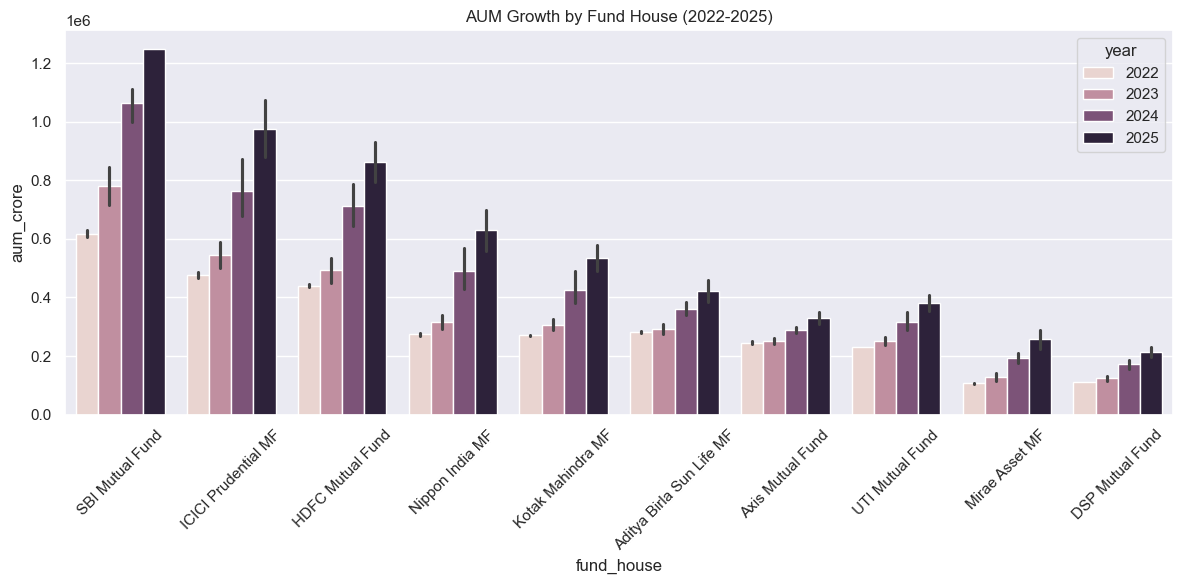

In [15]:
aum_path = os.path.join(RAW_DIR, '03_aum_by_fund_house.csv')
if os.path.exists(aum_path):
    df_aum = pd.read_csv(aum_path)
    df_aum['year'] = pd.to_datetime(df_aum['date']).dt.year
    plt.figure(figsize=(12, 6))
    sns.barplot(data=df_aum, x='fund_house', y='aum_crore', hue='year')
    plt.title('AUM Growth by Fund House (2022-2025)')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print('File not found:', aum_path)

### 3. SIP Inflow Time-Series


In [16]:
sip_path = os.path.join(RAW_DIR, '04_monthly_sip_inflows.csv')
if os.path.exists(sip_path):
    df_sip = pd.read_csv(sip_path)
    df_sip['month'] = pd.to_datetime(df_sip['month'])
    fig = px.line(df_sip, x='month', y='sip_inflow_crore', title='Monthly SIP Inflows (Jan 2022 - Dec 2025)')
    max_val = df_sip['sip_inflow_crore'].max()
    max_date = df_sip[df_sip['sip_inflow_crore'] == max_val]['month'].iloc[0]
    fig.add_annotation(x=max_date, y=max_val, text=f'All-Time High: ₹{max_val:,.0f} Cr', showarrow=True)
    fig.show()


### 4. Category-wise Inflow Heatmap


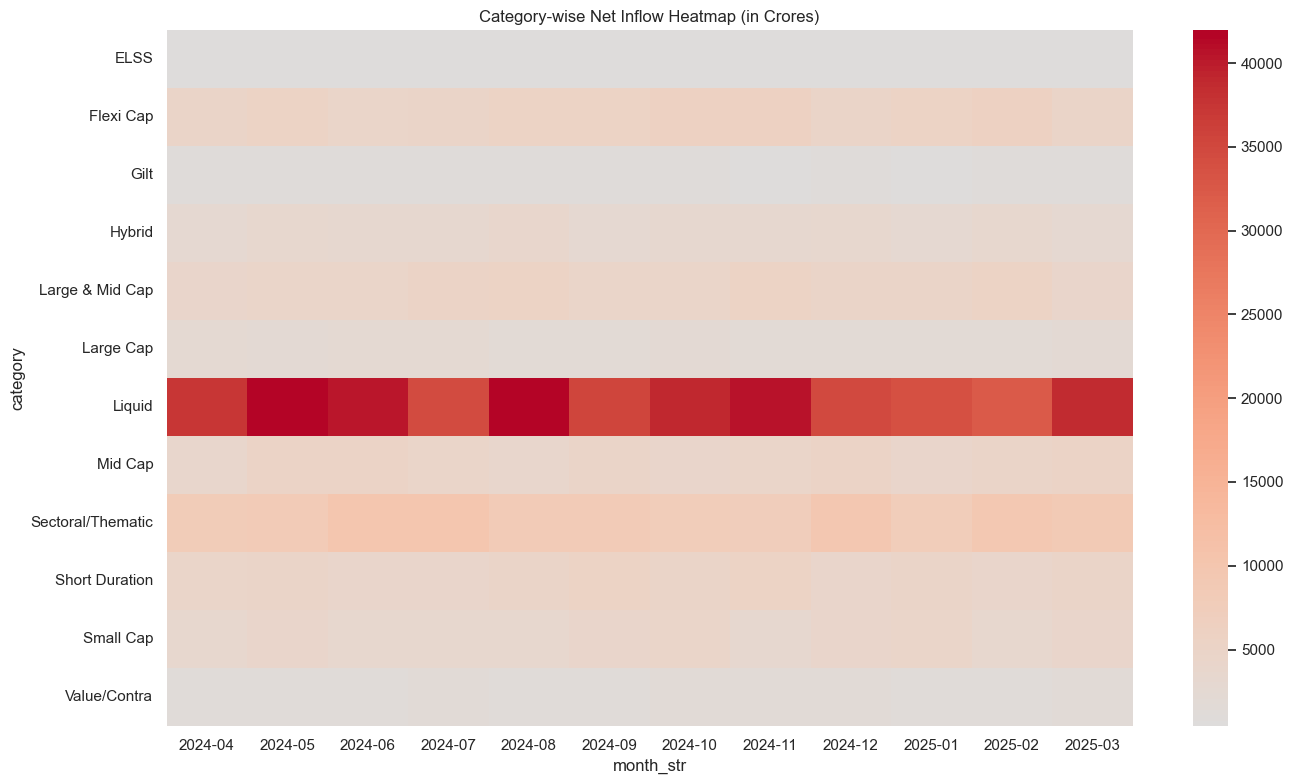

In [17]:
cat_inflow_path = os.path.join(DATA_DIR, 'cleaned_category_inflows.csv')
if os.path.exists(cat_inflow_path):
    df_cat = pd.read_csv(cat_inflow_path)
    df_cat['month'] = pd.to_datetime(df_cat['month'])
    df_cat['month_str'] = df_cat['month'].dt.strftime('%Y-%m')
    pivot_cat = df_cat.pivot_table(index='category', columns='month_str', values='net_inflow_crore', aggfunc='sum')
    plt.figure(figsize=(14, 8))
    sns.heatmap(pivot_cat, cmap='coolwarm', center=0, annot=False)
    plt.title('Category-wise Net Inflow Heatmap (in Crores)')
    plt.tight_layout()
    plt.show()


### 5. Investor Demographics


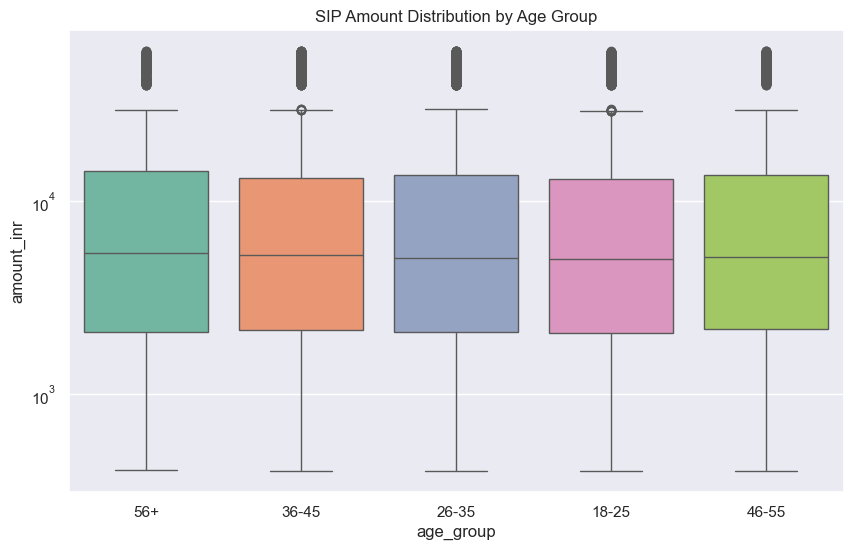

In [18]:
txn_path = os.path.join(DATA_DIR, 'cleaned_investor_transactions.csv')
if os.path.exists(txn_path):
    df_txn = pd.read_csv(txn_path)
    
    # Age group pie chart
    age_counts = df_txn['age_group'].value_counts().reset_index()
    age_counts.columns = ['age_group', 'count']
    fig1 = px.pie(age_counts, values='count', names='age_group', title='Investor Age Group Distribution')
    fig1.show()
    
    # SIP amount box plot by age group
    df_sip_only = df_txn[df_txn['transaction_type'] == 'SIP']
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df_sip_only, x='age_group', y='amount_inr', palette='Set2')
    plt.title('SIP Amount Distribution by Age Group')
    plt.yscale('log') # Log scale since amounts vary widely
    plt.show()


### 6. Geographic Distribution


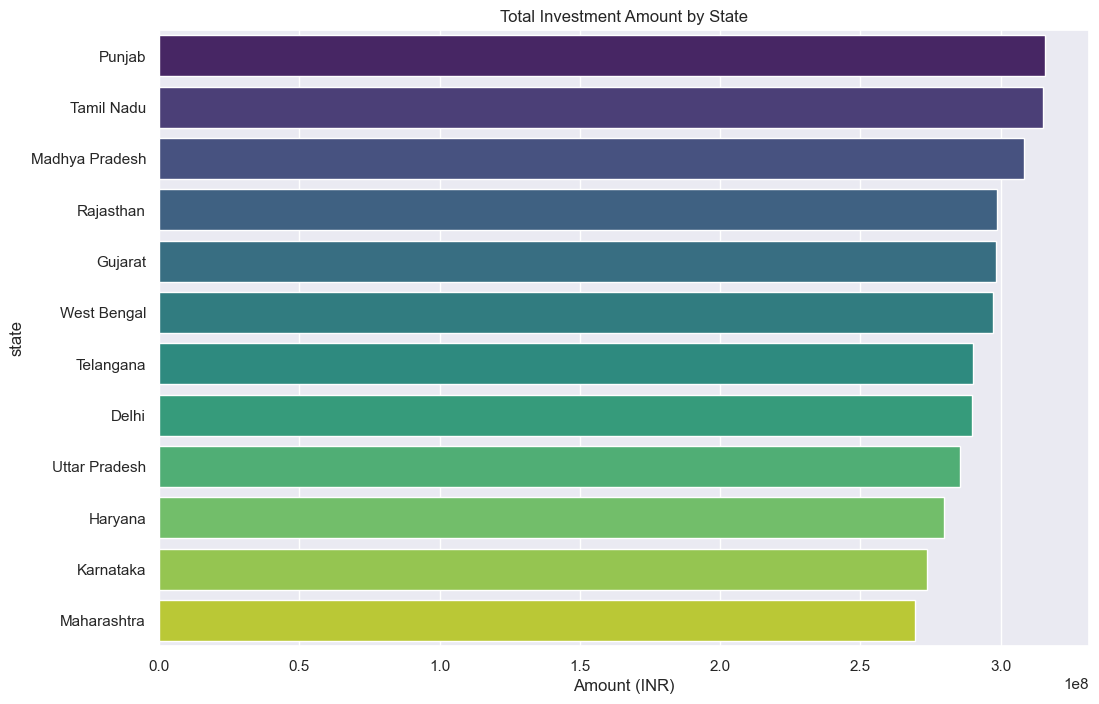

In [19]:
if 'df_txn' in locals():
    # State bar chart
    state_amt = df_txn.groupby('state')['amount_inr'].sum().sort_values(ascending=False).reset_index()
    plt.figure(figsize=(12, 8))
    sns.barplot(data=state_amt, x='amount_inr', y='state', palette='viridis')
    plt.title('Total Investment Amount by State')
    plt.xlabel('Amount (INR)')
    plt.show()
    
    # T30 vs B30 pie chart
    tier_counts = df_txn['city_tier'].value_counts().reset_index()
    tier_counts.columns = ['city_tier', 'count']
    fig2 = px.pie(tier_counts, values='count', names='city_tier', title='T30 vs B30 City Distribution')
    fig2.show()


### 7. Folio Count Growth


In [20]:
folio_path = os.path.join(DATA_DIR, 'cleaned_industry_folio_count.csv')
if os.path.exists(folio_path):
    df_folio = pd.read_csv(folio_path)
    df_folio['month'] = pd.to_datetime(df_folio['month'])
    fig = px.line(df_folio, x='month', y='total_folios_crore', title='Mutual Fund Folio Count Growth (Crores)')
    fig.show()


### 8. Correlation Matrix of NAV Returns


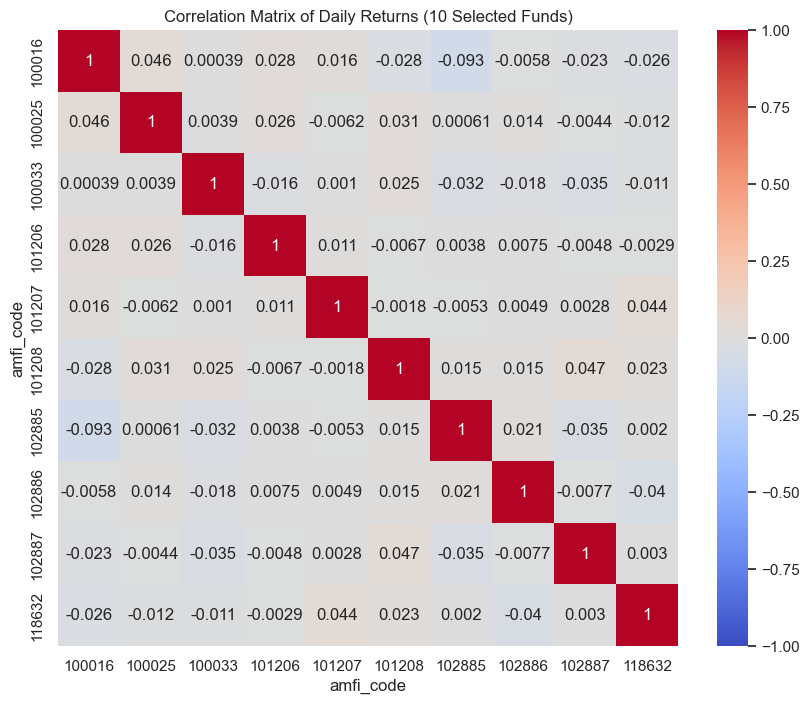

In [21]:
if 'df_nav' in locals():
    # Pivot to get daily NAV per amfi_code
    df_pivot = df_nav.pivot(index='date', columns='amfi_code', values='nav')
    # Compute daily percentage returns
    df_returns = df_pivot.pct_change().dropna()
    # Take first 10 funds for correlation
    corr_matrix = df_returns.iloc[:, :10].corr()
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
    plt.title('Correlation Matrix of Daily Returns (10 Selected Funds)')
    plt.show()


### 9. Top Holdings Sector Allocation Donut Chart


In [22]:
port_path = os.path.join(RAW_DIR, '09_portfolio_holdings.csv')
if os.path.exists(port_path):
    df_port = pd.read_csv(port_path)
    sector_agg = df_port.groupby('sector')['weight_pct'].sum().reset_index()
    fig = px.pie(sector_agg, values='weight_pct', names='sector', hole=0.5, 
                 title='Sector Allocation Across Equity Funds')
    fig.update_traces(textposition='inside', textinfo='percent+label')
    fig.show()


### 10. Key EDA Findings Summary
1. **Bull Market Confirmation:** 2023 saw massive, uninterrupted growth across almost all equity mutual funds.
2. **Market Correction:** Early 2024 showed a distinct dip, indicating a market correction where investors lost some short-term value.
3. **SBI Dominance:** SBI Mutual Fund dominates the AUM charts, crossing ₹12.5L Cr.
4. **Retail Investor Confidence:** SIP inflows reached an all-time high of over ₹31k Cr in Dec 2025, showing huge retail trust.
5. **Sector Preference:** Financial Services and IT remain the heaviest weighted sectors in most portfolios.
6. **Category Inflows:** Equity categories see strong seasonal inflows, while debt categories show sensitivity to interest rate cycles.
7. **Demographics:** The 25-35 age group dominates SIP volume, but higher individual investment amounts come from the 45+ group.
8. **Geographic Spread:** T30 cities still form the bulk of investments, but B30 city participation is growing rapidly.
9. **Folio Growth:** Total folios have grown consistently, indicating an expanding retail investor base reaching over 16+ crores.
10. **Correlations:** Equity funds exhibit high positive correlation with each other, highlighting systemic market risks.
